# Data Workshop 2



**Instructors:** Argen Smith (PO), Sophie Wynn (CS), Tommy Stone (AOS)

## Before the Workshop

### Installations
We expect that you will have Conda and VS Code installed on your computer before attending the workshop. If you need help we will have **office hours** to help with installs and troubleshoot issues from 12:30pm - 1:25pm in Munk Lab 303 on 09/18. 

See the below website for instructions to install
1) [Python Installation with Conda](https://eldavenport.github.io/SIO-PythonEarthScience/)
2) [VSCode Installation](https://eldavenport.github.io/SIO-PythonEarthScience/installation/software_install/vscode_install.html)

### Github Repository

All notebooks can be found on the [Math Workshop Github](https://github.com/tgstone/sio-math-workshop/)


### Data
You can download the available datasets that we will used for the workshop from our [data folder on Google drive](https://drive.google.com/drive/folders/1csB0khdMHT0-xp3sEaG3N3kgKTbG-lbO?usp=drive_link). You will need your UCSD google account to access the site.

In [ ]:
# importing libraries for this workshop

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cmocean import cm

## 1) Interpolation and weighted means over the California Current System

Teacher: Tommy Stone
TA: Sophie Wynn, Argen Smith

Often times we will have datasets with missing or incorrect points. These values can be either filled with 

- large or small numbers that are not possible in our variable range
- Not A Number (NaN) values. 
  
In this section we will explore the global Sea Surface Temperature dataset to interpolate between missing years. After the instruction section we will interpolate over a region to create a smaller grid and compare the temperature values with a reanalysis product. 

## DATASETS REQUIRED

We will be using the below datasets. You can download this notebook and run directly 

- sst_monthly_nans.nc
- sst_monthlymean.nc  
- sst.oisst.mon.ltm.1992-2020.nc


### Let's go ahead and load the sst_monthly_nans.nc file. A couple of review questions

1) What is the period of the data? (from when to when)
2) What are the units of the Sea Surface Temperature (SST)?

In [ ]:
# constants
data_path = "data/sst_monthly_nans.nc"
xr_sst = xr.open_dataset(data_path)
xr_sst

<xarray.Dataset> Size: 36MB
Dimensions:  (lat: 89, lon: 180, time: 559)
Coordinates:
  * lat      (lat) float32 356B 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time     (time) datetime64[ns] 4kB 1980-01-01 1980-02-01 ... 2026-07-01
Data variables:
    sst      (time, lat, lon) float32 36MB ...

### Slicing the data

The goal of this section is that we want to compare the 20-year average over two periods near the CCS. The periods are 

- Period 1: 1985 - 2004
- Period 2: 2005 - 2024


In [ ]:
# California Current System bounding box (0-360 longitude convention)
# Latitude is stored decreasing from 88 to -88 so decreasing
ccs_lon = slice(220, 250)
ccs_lat = slice(45, 20)  

ccs_sst = xr_sst.sst.sel(lon=ccs_lon, lat=ccs_lat)

# creating the time periods where we want to slice the data
periods = [("1985-2004", "1985-01-01", "2004-12-31"),
           ("2005-2024", "2005-01-01", "2024-12-31")]

period_data = []
period_means = []
period_vars = []

for label, start, end in periods:
    period_data_tmp = ccs_sst.sel(time=slice(start, end))
    period_data.append(period_data_tmp)
    period_means.append(period_data_tmp.mean(dim="time", skipna = False))
    period_vars.append(period_data_tmp.var(dim="time", skipna = False))

# shared color limits: one scale for the means, one for the variances
mean_vmin = np.nanmin([np.nanmin(pm) for pm in period_means])
mean_vmax = np.nanmax([np.nanmax(pm) for pm in period_means])
var_vmin = np.nanmin([np.nanmin(pv) for pv in period_vars])
var_vmax = np.nanmax([np.nanmax(pv) for pv in period_vars])


### Plot the comparisons

### Question

1) Why is the 1985 - 2004 period blank?

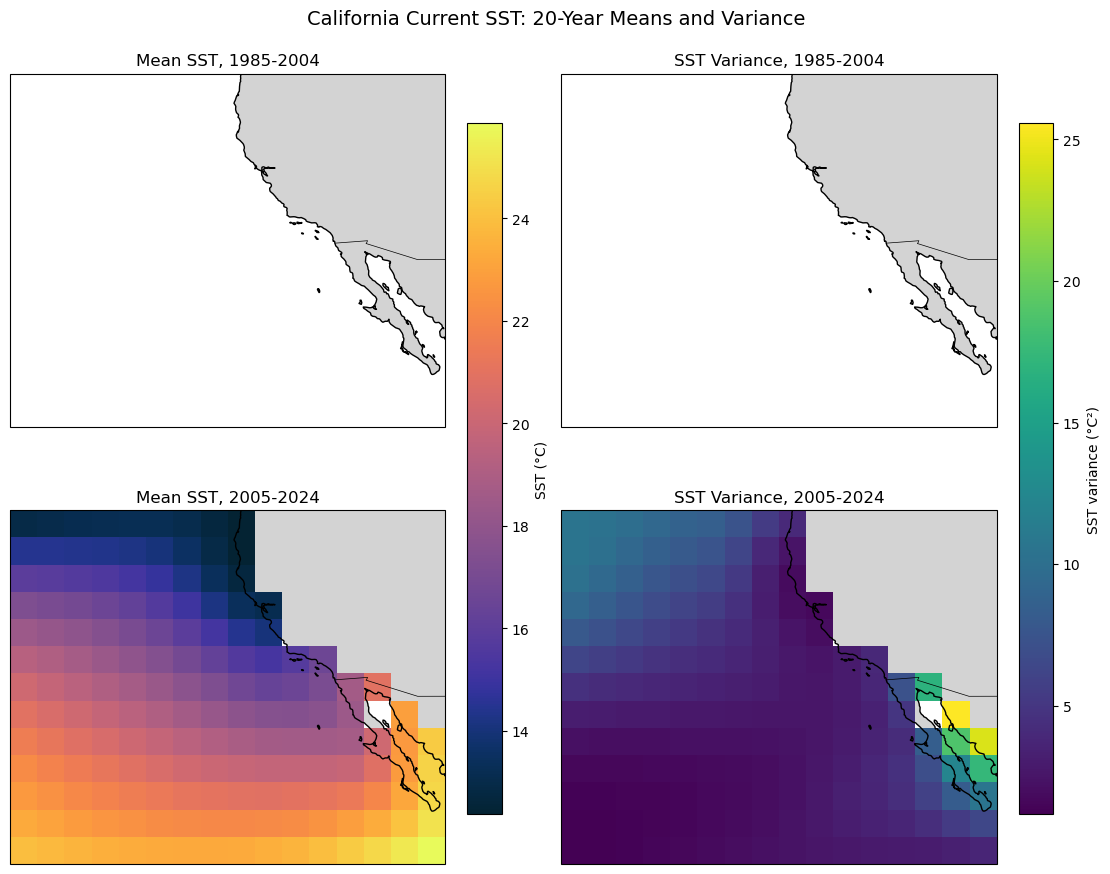

In [5]:
fig, axs = plt.subplots(
    2, 2, figsize=(11, 9),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)

for row, ((label, start, end), pm, pv) in enumerate(zip(periods, period_means, period_vars)):
    ax_mean, ax_var = axs[row]

    im_mean = pm.plot.pcolormesh(
        ax=ax_mean, x="lon", y="lat",
        vmin=mean_vmin, vmax=mean_vmax,
        cmap=cm.thermal,
        transform=ccrs.PlateCarree(),
        add_colorbar=False,
    )
    im_var = pv.plot.pcolormesh(
        ax=ax_var, x="lon", y="lat",
        vmin=var_vmin, vmax=var_vmax,
        cmap="viridis",
        transform=ccrs.PlateCarree(),
        add_colorbar=False,
    )

    for ax in (ax_mean, ax_var):
        ax.coastlines()
        ax.add_feature(cfeature.LAND, facecolor="lightgray")
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    ax_mean.set_title(f"Mean SST, {label}")
    ax_var.set_title(f"SST Variance, {label}")

fig.colorbar(im_mean, ax=axs[:, 0], orientation="vertical", shrink=0.8, label="SST (°C)")
fig.colorbar(im_var, ax=axs[:, 1], orientation="vertical", shrink=0.8, label="SST variance (°C²)")
fig.suptitle("California Current SST: 20-Year Means and Variance", fontsize=14)
plt.show()

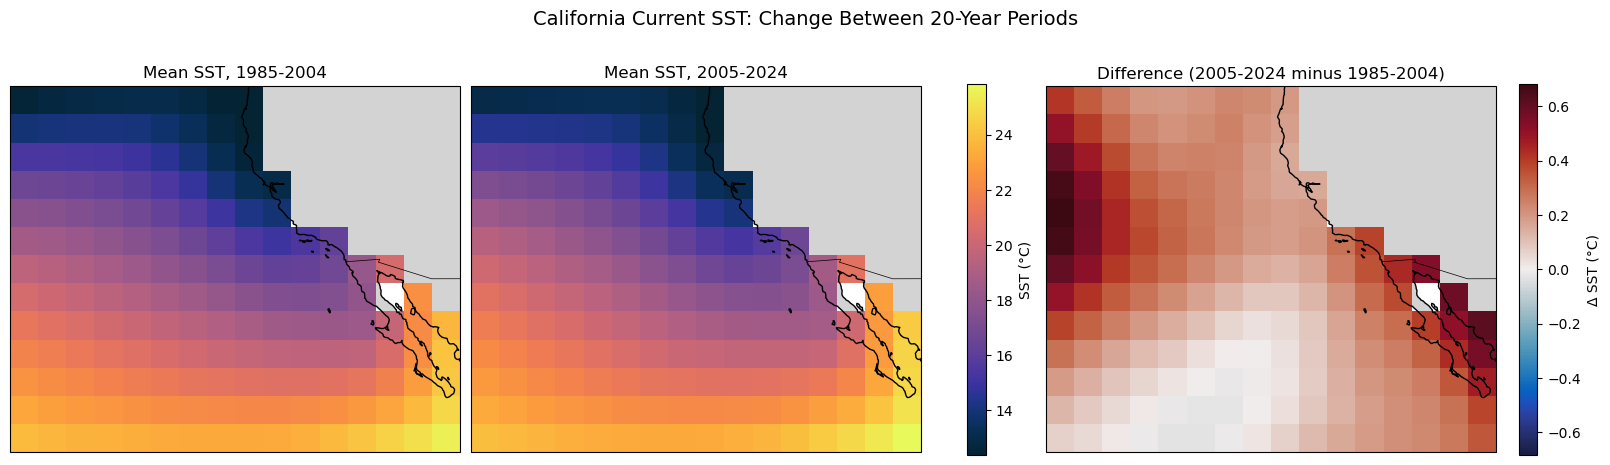

In [13]:
diff = period_means[1] - period_means[0]
diff_abs_max = np.abs(diff).max().item()

fig, axs = plt.subplots(
    1, 3, figsize=(16, 5),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)

im_mean0 = period_means[0].plot.pcolormesh(
    ax=axs[0], x="lon", y="lat",
    vmin=mean_vmin, vmax=mean_vmax,
    cmap=cm.thermal,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
)
axs[0].set_title(f"Mean SST, {periods[0][0]}")

im_mean1 = period_means[1].plot.pcolormesh(
    ax=axs[1], x="lon", y="lat",
    vmin=mean_vmin, vmax=mean_vmax,
    cmap=cm.thermal,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
)
axs[1].set_title(f"Mean SST, {periods[1][0]}")

im_diff = diff.plot.pcolormesh(
    ax=axs[2], x="lon", y="lat",
    vmin=-diff_abs_max, vmax=diff_abs_max,
    cmap=cm.balance,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
)
axs[2].set_title(f"Difference ({periods[1][0]} minus {periods[0][0]})")

for ax in axs:
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

fig.colorbar(im_mean1, ax=axs[:2], orientation="vertical", shrink=0.8, label="SST (°C)")
fig.colorbar(im_diff, ax=axs[2], orientation="vertical", shrink=0.8, label="Δ SST (°C)")
fig.suptitle("California Current SST: Change Between 20-Year Periods", fontsize=14)
plt.show()

### 1a) Linear Interpolation with Xarray



In [ ]:
sst_period0 = period_data[0]

# drop timesteps that are entirely missing, then interpolate back onto the full time axis
sst_valid = sst_period0.dropna(dim="time", how="all")
sst_filled = sst_valid.interp_like(sst_period0.time, method="linear")

print("NaNs in 2000 before interpolation:", int(sst_period0.sel(time="2000").isnull().sum()))
print("NaNs in 2000 after interpolation: ", int(sst_filled.sel(time="2000").isnull().sum()))

NaNs in 2000 before interpolation: 2496
NaNs in 2000 after interpolation:  492


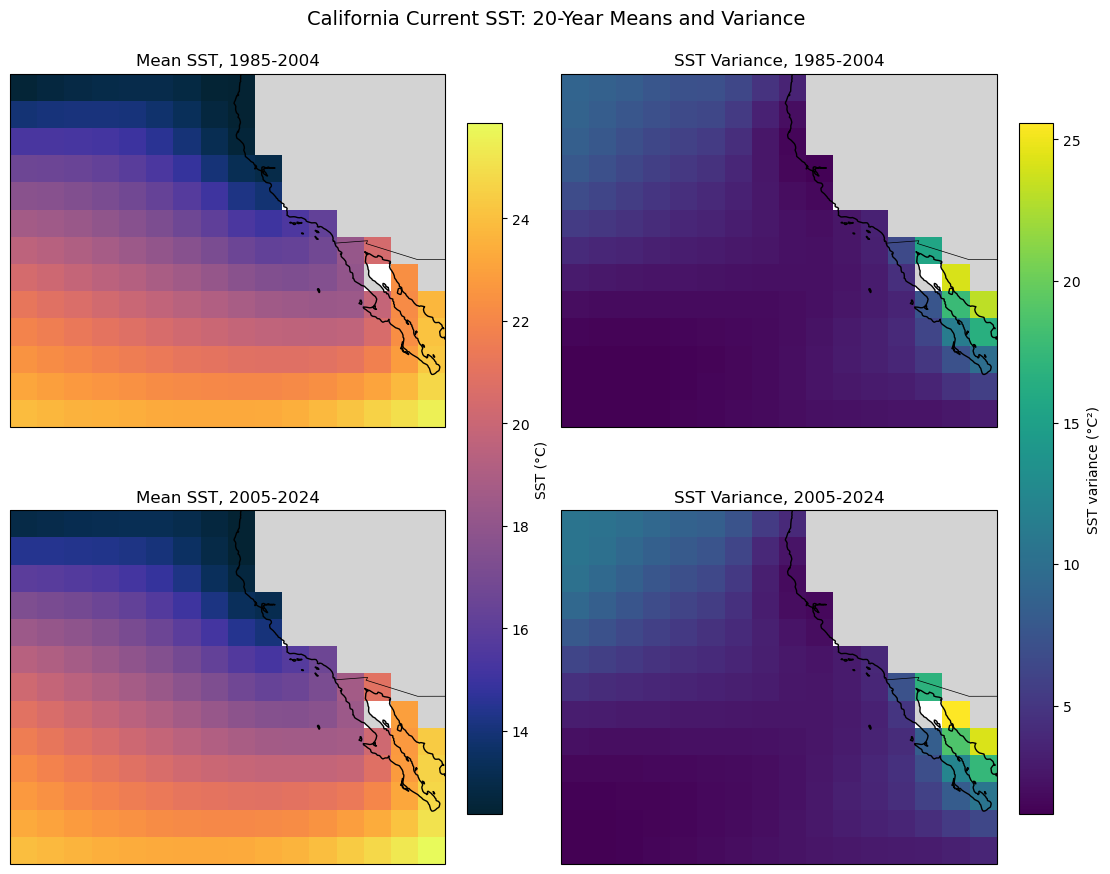

In [8]:
sst_filled_mean = sst_filled.mean(dim="time", skipna = False)
sst_filled_var = sst_filled.var(dim = "time", skipna = False)

period_means[0] = sst_filled_mean
period_vars[0] = sst_filled_var

fig, axs = plt.subplots(
    2, 2, figsize=(11, 9),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)

for row, ((label, start, end), pm, pv) in enumerate(zip(periods, period_means, period_vars)):
    ax_mean, ax_var = axs[row]

    im_mean = pm.plot.pcolormesh(
        ax=ax_mean, x="lon", y="lat",
        vmin=mean_vmin, vmax=mean_vmax,
        cmap=cm.thermal,
        transform=ccrs.PlateCarree(),
        add_colorbar=False,
    )
    im_var = pv.plot.pcolormesh(
        ax=ax_var, x="lon", y="lat",
        vmin=var_vmin, vmax=var_vmax,
        cmap="viridis",
        transform=ccrs.PlateCarree(),
        add_colorbar=False,
    )

    for ax in (ax_mean, ax_var):
        ax.coastlines()
        ax.add_feature(cfeature.LAND, facecolor="lightgray")
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    ax_mean.set_title(f"Mean SST, {label}")
    ax_var.set_title(f"SST Variance, {label}")

fig.colorbar(im_mean, ax=axs[:, 0], orientation="vertical", shrink=0.8, label="SST (°C)")
fig.colorbar(im_var, ax=axs[:, 1], orientation="vertical", shrink=0.8, label="SST variance (°C²)")
fig.suptitle("California Current SST: 20-Year Means and Variance", fontsize=14)
plt.show()

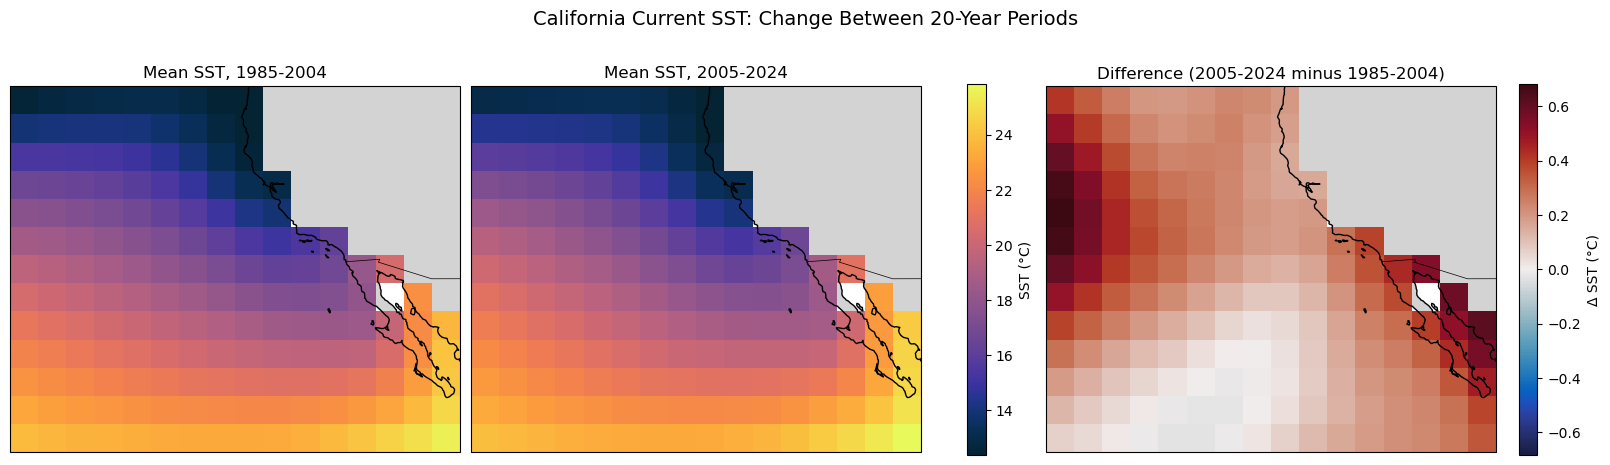

In [9]:
diff = period_means[1] - period_means[0]
diff_abs_max = np.abs(diff).max().item()

fig, axs = plt.subplots(
    1, 3, figsize=(16, 5),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)

im_mean0 = period_means[0].plot.pcolormesh(
    ax=axs[0], x="lon", y="lat",
    vmin=mean_vmin, vmax=mean_vmax,
    cmap=cm.thermal,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
)
axs[0].set_title(f"Mean SST, {periods[0][0]}")

im_mean1 = period_means[1].plot.pcolormesh(
    ax=axs[1], x="lon", y="lat",
    vmin=mean_vmin, vmax=mean_vmax,
    cmap=cm.thermal,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
)
axs[1].set_title(f"Mean SST, {periods[1][0]}")

im_diff = diff.plot.pcolormesh(
    ax=axs[2], x="lon", y="lat",
    vmin=-diff_abs_max, vmax=diff_abs_max,
    cmap=cm.balance,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
)
axs[2].set_title(f"Difference ({periods[1][0]} minus {periods[0][0]})")

for ax in axs:
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

fig.colorbar(im_mean1, ax=axs[:2], orientation="vertical", shrink=0.8, label="SST (°C)")
fig.colorbar(im_diff, ax=axs[2], orientation="vertical", shrink=0.8, label="Δ SST (°C)")
fig.suptitle("California Current SST: Change Between 20-Year Periods", fontsize=14)
plt.show()

## 1c) Your Turn

In [ ]:
# OISST climatology
oisst = xr.open_dataset("data/sst.oisst.mon.ltm.1991-2020.nc", decode_times=False)

# OISST lat runs south-to-north (ascending)
oisst_ccs_lat = slice(20, 45)
oisst_ccs = oisst.sst.sel(lon=ccs_lon, lat=oisst_ccs_lat)

# take mean over the entire time period
oisst_mean = oisst_ccs.mean(dim="time")

In [ ]:
# mean from the monthly-mean product over the same 1991-2020 period
sst_mean_1991_2020 = (
    xr.open_dataset("data/sst_monthlymean.nc")
    .sst.sel(lon=ccs_lon, lat=ccs_lat)
    .sel(time=slice("1991-01-01", "2020-12-31"))
    .mean(dim="time")
)

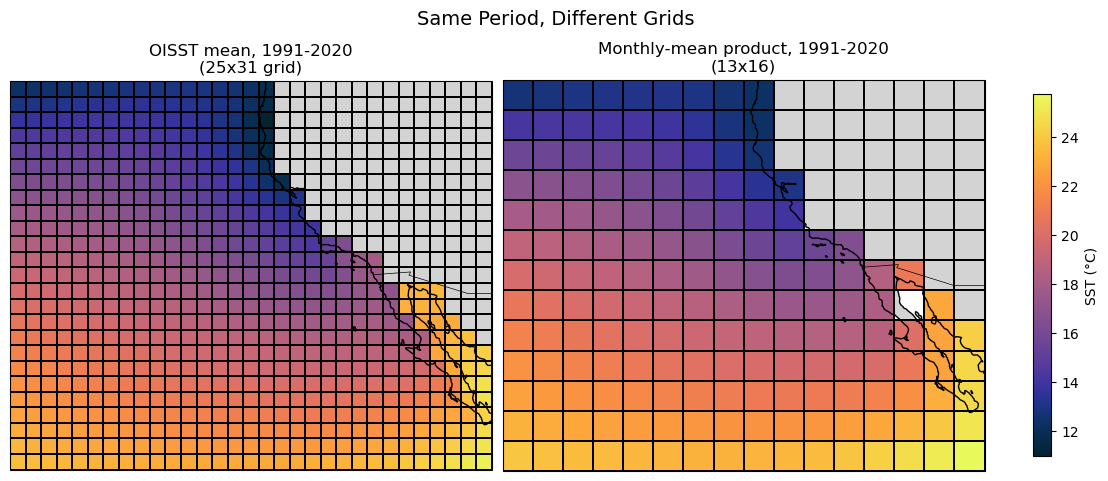

In [ ]:
native_vmin = min(oisst_mean.min().item(), sst_mean_1991_2020.min().item())
native_vmax = max(oisst_mean.max().item(), sst_mean_1991_2020.max().item())

fig, axs = plt.subplots(
    1, 2, figsize=(11, 5),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)

im_oisst_native = oisst_mean.plot.pcolormesh(
    ax=axs[0], x="lon", y="lat",
    vmin=native_vmin, vmax=native_vmax,
    cmap=cm.thermal,
    transform=ccrs.PlateCarree(),
    edgecolor="k", linewidth=0.05,
    add_colorbar=False,
)
axs[0].set_title(f"OISST mean, 1991-2020\n({oisst_mean.sizes['lat']}x{oisst_mean.sizes['lon']} grid)")

im_monthly_native = sst_mean_1991_2020.plot.pcolormesh(
    ax=axs[1], x="lon", y="lat",
    vmin=native_vmin, vmax=native_vmax,
    cmap=cm.thermal,
    transform=ccrs.PlateCarree(),
    edgecolor="k", linewidth=0.3,
    add_colorbar=False,
)
axs[1].set_title(f"Monthly-mean product, 1991-2020\n({sst_mean_1991_2020.sizes['lat']}x{sst_mean_1991_2020.sizes['lon']})")

for ax in axs:
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

fig.colorbar(im_monthly_native, ax=axs, orientation="vertical", shrink=0.8, label="SST (°C)")
fig.suptitle("Same Period, Different Grids", fontsize=14)
plt.show()

### SOLUTION

In [ ]:
# interpolate the coarser 2deg product onto OISST's finer 0.25deg grid,
# so we can compare/difference the two products point-by-point
monthly_on_oisst_grid = sst_mean_1991_2020.interp_like(oisst_mean)

diff = oisst_mean - monthly_on_oisst_grid
diff.name = "sst"

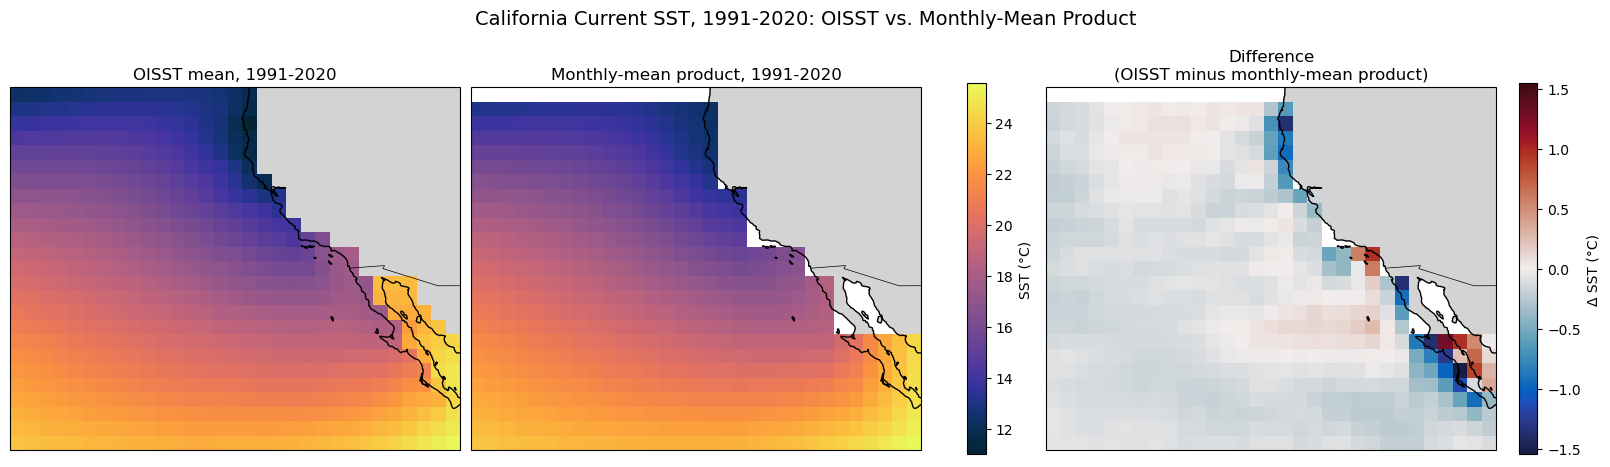

In [18]:
prod_vmin = min(oisst_mean.min().item(), monthly_on_oisst_grid.min().item())
prod_vmax = max(oisst_mean.max().item(), monthly_on_oisst_grid.max().item())
diff_abs_max = np.abs(diff).max().item()

fig, axs = plt.subplots(
    1, 3, figsize=(16, 5),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)

im_oisst = oisst_mean.plot.pcolormesh(
    ax=axs[0], x="lon", y="lat",
    vmin=prod_vmin, vmax=prod_vmax,
    cmap=cm.thermal,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
)
axs[0].set_title("OISST mean, 1991-2020")

im_monthly = monthly_on_oisst_grid.plot.pcolormesh(
    ax=axs[1], x="lon", y="lat",
    vmin=prod_vmin, vmax=prod_vmax,
    cmap=cm.thermal,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
)
axs[1].set_title("Monthly-mean product, 1991-2020")

im_diff = diff.plot.pcolormesh(
    ax=axs[2], x="lon", y="lat",
    vmin=-diff_abs_max, vmax=diff_abs_max,
    cmap=cm.balance,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
)
axs[2].set_title("Difference\n(OISST minus monthly-mean product)")

for ax in axs:
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

fig.colorbar(im_monthly, ax=axs[:2], orientation="vertical", shrink=0.8, label="SST (°C)")
fig.colorbar(im_diff, ax=axs[2], orientation="vertical", shrink=0.8, label="Δ SST (°C)")
fig.suptitle("California Current SST, 1991-2020: OISST vs. Monthly-Mean Product", fontsize=14)
plt.show()

## 2) Basic Statistics with Scipy
Teacher: Argen Smith
TA: Sophie Wynn, Tommy Stone

## 3) Machine Learning with SKlearn 
Teacher: Sophie Wynn
TAs: Argen Smith, Tommy Stone
